# Brecha de género en el ingreso laboral de Bogotá

GEIH 2018. Brechas de medias logarítmicas y comparaciones condicionales.

## 1. Marco y ponderación

Se usa $w_i=\texttt{fex\_c}_i$ para que cada registro contribuya según la cantidad de personas que representa en Bogotá, en vez de dar el mismo peso a cada fila de la muestra. El objetivo corresponde a ocupados de 18 años o más con ingreso positivo observado; los pesos no recuperan automáticamente a quienes no reportaron ingreso. La suma de pesos es una estimación de población, no el tamaño muestral empleado para los grados de libertad.

Para $X$ y $\Omega=\operatorname{diag}(w_i)$ se estima mínimos cuadrados ponderados:
$$\hat\beta_w=\arg\min_b\sum_i w_i(y_i-x_i'b)^2=(X'\Omega X)^{-1}X'\Omega y.$$
La implementación usa una factorización estable y pseudoinversa si hay columnas redundantes. Multiplicar todos los pesos por una constante no cambia el estimador. Se reporta
$$R_w^2=1-\frac{\sum_iw_i\hat u_i^2}{\sum_iw_i(y_i-\bar y_w)^2},\qquad \mathrm{RMSE}_w=\sqrt{\frac{\sum_i w_i\hat u_i^2}{\sum_iw_i}}.$$
La covarianza analítica es el sándwich HC1 ponderado, con $k=\operatorname{rango}(X)$:
$$\hat V_w=\frac{n}{n-k}(X'\Omega X)^{-1}\left(\sum_iw_i^2\hat u_i^2x_ix_i'\right)(X'\Omega X)^{-1}.$$
El factor de expansión no es un peso de precisión inversa. Por eso la inferencia principal usa HC1 y bootstrap, en lugar de atribuirle una interpretación homoscedástica al error clásico ponderado. Estas aproximaciones por personas no reproducen estratos y conglomerados del diseño completo del DANE.

### Personas representadas y precisión del total
Para el conjunto de registros $G$ utilizado en cada estimación se reportan dos cantidades distintas:
$$n_G=\sum_{i\in G}1,\qquad \widehat N_G=\sum_{i\in G}\texttt{fex\_c}_i.$$
$n_G$ cuenta observaciones y $\widehat N_G$ estima las personas representadas en la escala del archivo. Se suman los factores originales, sin normalizarlos a media uno. Los totales se presentan redondeados a personas; las tablas CSV conservan precisión completa. El total corresponde al grupo efectivamente incluido, no a todos los habitantes de Bogotá.

No se reporta IC del total poblacional: el archivo no suministra estratos de muestreo y unidades primarias identificados como tales, ni pesos replicados o información suficiente de calibración para estimar su varianza de diseño. `estrato1` es estrato socioeconómico y las llaves de hogar no sustituyen esa información. Un IC requeriría $\widehat N_G\pm1.96\widehat{EE}_{diseño}(\widehat N_G)$. La dispersión de los pesos o un bootstrap uniforme de su suma no recuperan por sí solos esa precisión. No disponible no significa incertidumbre cero. [Referencia sobre totales e inferencia de encuestas](https://search.r-project.org/CRAN/refmans/survey/html/surveysummary.html).

Los IC HC1 y bootstrap ya mostrados corresponden a medias, coeficientes o picos bajo la aproximación por personas descrita en el análisis; no son IC de $\widehat N_G$. Los grupos superpuestos y los modelos ajustados a las mismas personas no deben sumarse.

In [1]:
from pathlib import Path
import os,sys
ROOT=Path(os.environ.get('PS1_GEIH2018_DIR',Path.cwd())).resolve()
while not (ROOT/'datos/src').is_dir() and ROOT.parent!=ROOT:ROOT=ROOT.parent
sys.path.insert(0,str(ROOT));sys.path.insert(0,str(ROOT/'punto2_brecha_genero/src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
from src.reportes import tabla,nota_poblacion
import analisis_brecha as a
plt.rcParams.update({'font.size':11,'axes.titleweight':'normal','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':.18,'legend.frameon':False})
m=a.cargar()
nota_poblacion(m)

Muestra de estimación: 14,763 registros; aproximadamente 3,686,406 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

## 2. Datos: en qué se diferencian hombres y mujeres ocupados
El panel (d) es incondicional respecto de educación, horas y empleo: calcula la media de log-ingreso dentro de cada combinación de edad $a$ y sexo $s$ sin ajustar por esos controles.
$$\hat\mu_{as}=\frac{\sum_{i:A_i=a,S_i=s}w_iy_i}{\sum_{i:A_i=a,S_i=s}w_i},\qquad \widehat{EE}_{as}^2=\frac{n_{as}}{n_{as}-1}\frac{\sum_{i\in(as)}w_i^2(y_i-\hat\mu_{as})^2}{(\sum_{i\in(as)}w_i)^2}.$$
Sí es posible construir intervalos para cada edad: se muestra $\hat\mu_{as}\pm1.96\widehat{EE}_{as}$ cuando hay al menos 15 observaciones en la celda. Las barras son puntuales y no una banda simultánea; describen incertidumbre del promedio, no dispersión individual. Las celdas pequeñas no se dibujan, pero permanecen en las regresiones.

Descriptivas de género: 14,763 registros; aproximadamente 3,686,406 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

female,age,media,sd,ee,n,poblacion,n_efectivo,IC_inf,IC_sup
0,18,13.2231,0.6709,0.0870,78,19685.4722,72.4260,13.0527,13.3936
0,19,13.3011,0.7510,0.0675,128,30697.1998,122.6764,13.1688,13.4335
0,20,13.4393,0.6858,0.0572,144,35049.1711,134.8692,13.3272,13.5513
0,21,13.6144,0.5710,0.0423,178,42223.4927,170.6311,13.5314,13.6974
0,22,13.6795,0.6204,0.0454,195,46464.5485,186.5242,13.5904,13.7685
0,23,13.7741,0.5693,0.0406,209,51242.1889,192.9171,13.6945,13.8538
0,24,13.8628,0.5188,0.0359,249,61138.9743,234.8833,13.7925,13.9332
0,25,13.9119,0.6251,0.0400,254,64548.1682,241.5907,13.8336,13.9902
0,26,13.9835,0.5388,0.0351,242,62143.0596,230.2629,13.9146,14.0523
0,27,13.9303,0.6040,0.0390,235,60154.0897,221.2363,13.8539,14.0067


female,oficio_grupo,n_muestra,personas_representadas
0,Administrativos,814,202553
0,Agropecuarios,48,11646
0,Comerciantes y vendedores,1120,284837
0,Directivos,291,74802
0,Operarios y transporte,3061,776359
0,Profesionales y tecnicos,1386,339481
0,Servicios,1054,268193
1,Administrativos,1277,315112
1,Agropecuarios,11,2643
1,Comerciantes y vendedores,1217,303396


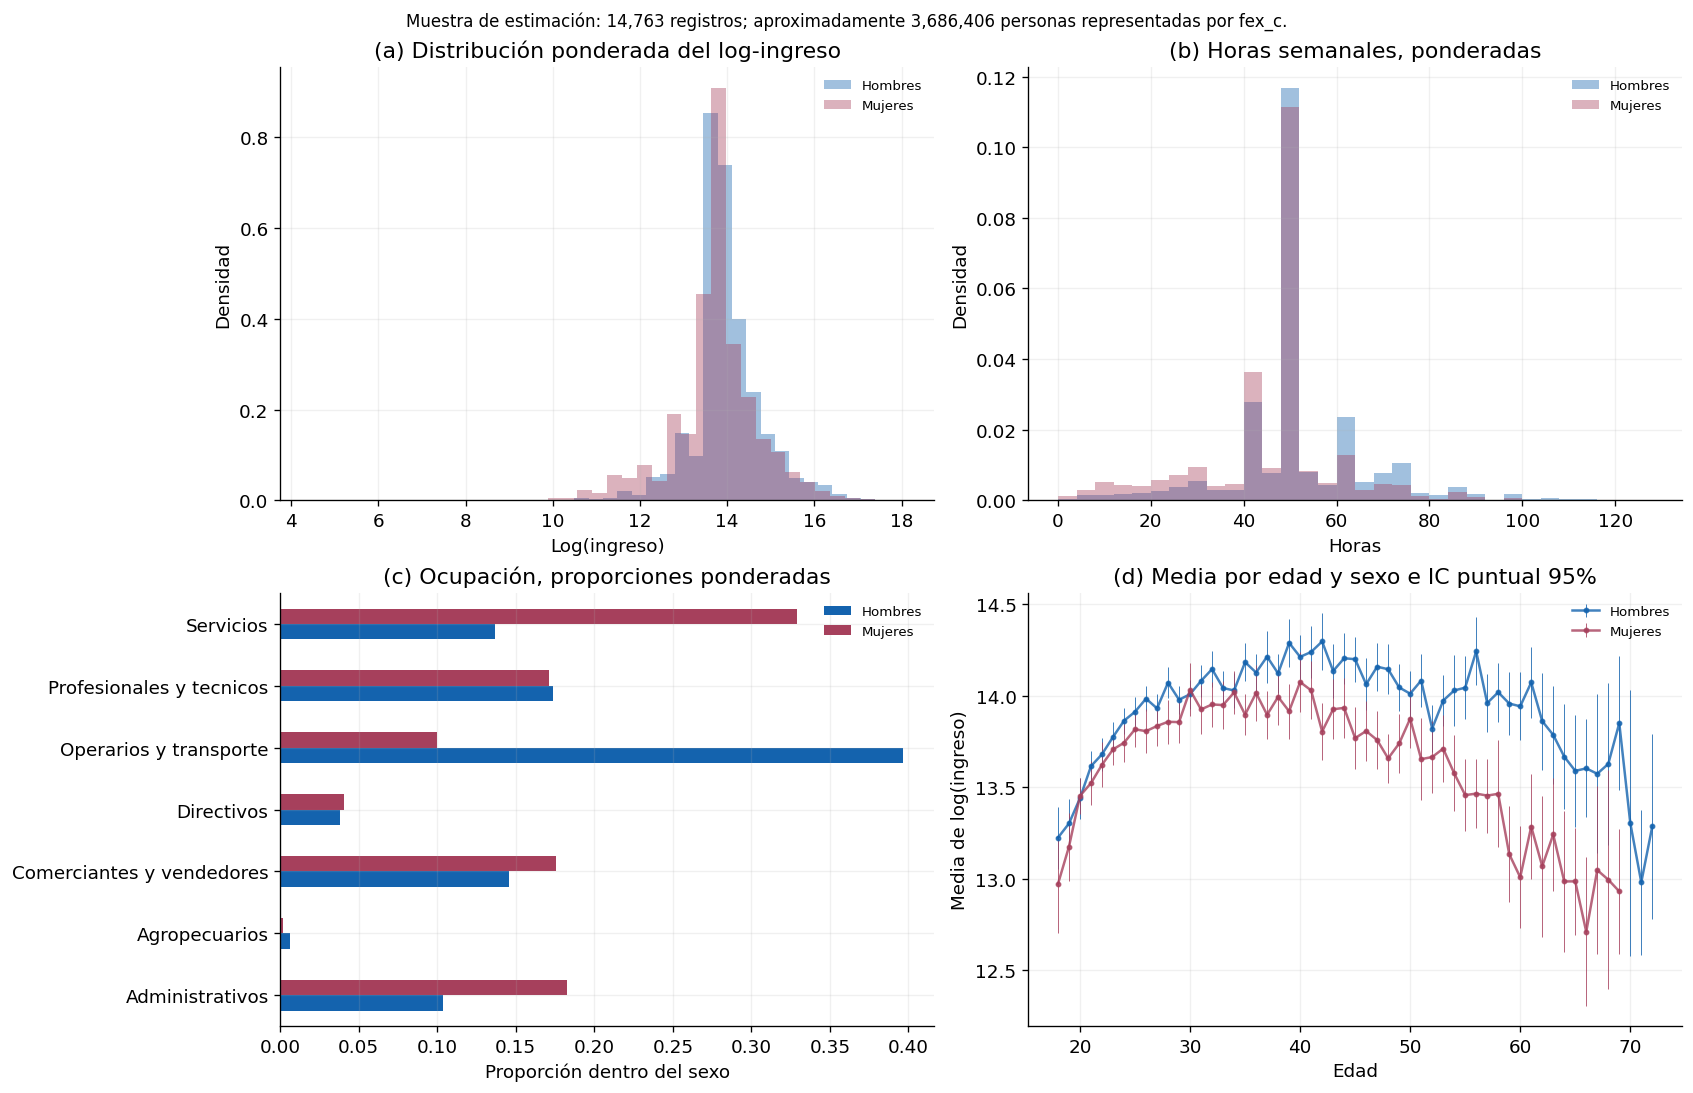

sexo,n,poblacion_representada,age,anios_educ,totalHoursWorked,terciaria,formal
Hombres,7774,1957870.0974,38.8125,11.0898,50.4690,0.3697,0.6022
Mujeres,6989,1728535.6449,38.5362,11.6536,44.7545,0.4508,0.6017


In [2]:
descriptivas=a.descriptivas(m)

## 3. Brecha incondicional
$$y_i=\alpha+\delta F_i+u_i,\qquad \hat\delta_w=\bar y_{M,w}-\bar y_{H,w}.$$
Con $F_i=1$ para mujeres, $100[\exp(\hat\delta_w)-1]$ es la brecha porcentual entre medias geométricas. No equivale a la brecha de medias aritméticas del ingreso. S0 de la siguiente tabla es esta regresión. Se excluye un caso sin educación para que todos los modelos de la escalera usen las mismas 14,763 personas.

## 4. Brecha condicional
### 4.1 La escalera de controles, estimada por FWL
Para cada conjunto $W_s$ (con intercepto) se estima $y=F\delta_s+W_s\gamma_s+u$. S1 añade edad y edad²; S2 educación; S3 horas y horas²; S4 vínculo, formalidad y tamaño de firma; S5 grupo ocupacional. S6 reemplaza grupo ocupacional por oficio detallado y S7 incorpora estrato y jefatura. S6 no es un modelo estrictamente anidado cuando la agrupación de oficios raros mezcla grupos.

Educación aproxima capital humano y edad experiencia y cohorte. Horas describe intensidad laboral; vínculo, formalidad, tamaño y ocupación comparan puestos similares. Estos controles laborales pueden ser mediadores de desigualdad o inducir selección, por lo que su inclusión no identifica discriminación causal. S5 es la comparación preferida de trabajadores y puestos similares, con un nivel de ocupación que conserva soporte.

FWL ponderado se implementa de forma explícita:
$$\hat\pi_y=(W_s'\Omega W_s)^{-1}W_s'\Omega y,\quad r_y=y-W_s\hat\pi_y,$$
$$\hat\pi_F=(W_s'\Omega W_s)^{-1}W_s'\Omega F,\quad r_F=F-W_s\hat\pi_F,$$
$$\hat\delta_s=\frac{r_F'\Omega r_y}{r_F'\Omega r_F},\quad \hat u=r_y-r_F\hat\delta_s.$$
Es el mismo coeficiente y residuo de la regresión completa ponderada. Computacionalmente, equivale a FWL ordinario sobre $\sqrt\Omega y$, $\sqrt\Omega F$ y $\sqrt\Omega W_s$. La covarianza analítica del coeficiente es
$$\widehat{Var}_{HC1}(\hat\delta_s)=\frac{n}{n-k_s}\frac{\sum_iw_i^2r_{F,i}^2\hat u_i^2}{(\sum_iw_ir_{F,i}^2)^2},\quad k_s=\operatorname{rango}([W_s,F]).$$
Los grados de libertad corresponden a la regresión completa, no solo a los dos elementos que aparecen en la segunda etapa.

### Inferencia bootstrap y comparación de precisión
Se sigue el bootstrap no paramétrico por filas de la [clase 3 del profesor](https://github.com/ignaciomsarmiento/BDML_2026_20/blob/main/Lecture03/Lecture_03_bootstrap.ipynb): extraer $n$ índices con reemplazo, evaluar la función estadística y repetir $B$ veces. Es la lógica de `boot(data, statistic, R)` implementada con NumPy en Python. Cada fila conserva conjuntamente $(y_i,x_i,w_i)$; se remuestrea uniformemente entre registros y se vuelve a aplicar su peso dentro del ajuste. No se sortea con probabilidad proporcional a $w_i$ y después se pondera otra vez.

Con réplicas $\hat\theta_1^*,\ldots,\hat\theta_B^*$, se calculan
$$\widehat{EE}_{boot}=\sqrt{\frac{\sum_b(\hat\theta_b^*-\bar\theta^*)^2}{B-1}},\qquad IC_{95\%,perc}=[q_{.025}(\hat\theta^*),q_{.975}(\hat\theta^*)].$$
La semilla es 2026. El método conserva la lógica del curso; no produce necesariamente los mismos sorteos que R aun usando la misma semilla. El intervalo percentil y el método delta se interpretan bajo la aproximación de muestreo por personas descrita arriba.
Se repiten ambas proyecciones FWL en cada réplica: 500 para S0-S7 y 1,000 para S5. Se reportan errores analíticos HC1, errores bootstrap, intervalos percentiles y $R_w^2$ completo. Las diferencias de brecha al agregar controles son cambios de comparación, no contribuciones causales.

En la muestra ponderada, las mujeres tienen mayor escolaridad media y trabajan menos horas semanales. Al ajustar por educación, la brecha se vuelve más negativa: la comparación deja de recoger su ventaja educativa observada. Al añadir horas, la brecha se reduce en magnitud, de forma consistente con la menor jornada media femenina. Los controles posteriores comparan condiciones de empleo más próximas. Estos cambios no deben interpretarse como porcentajes de desigualdad causados por cada bloque.

Muestra original de S0-S7, base del bootstrap: 14,763 registros; aproximadamente 3,686,406 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

modelo,beta_Female,brecha_porcentual,EE_analitico_HC1,EE_bootstrap,IC_percentil_inf,IC_percentil_sup,R2_ponderado,rango,n,diferencia_FWL,personas_representadas
S0,-0.2405,-21.3729,0.0152,0.0159,-0.2692,-0.2096,0.0180,2,14763,0.0000,3686405.7423
S1,-0.2603,-22.9213,0.0147,0.0154,-0.2894,-0.2306,0.0733,4,14763,0.0000,3686405.7423
S2,-0.3220,-27.5299,0.0132,0.0136,-0.3477,-0.2945,0.2668,9,14763,0.0000,3686405.7423
S3,-0.2119,-19.0972,0.0119,0.0125,-0.2340,-0.1850,0.4098,11,14763,0.0000,3686405.7423
S4,-0.1989,-18.0373,0.0113,0.0119,-0.2199,-0.1736,0.5033,21,14763,0.0000,3686405.7423
S5,-0.1833,-16.7520,0.0115,0.0116,-0.2051,-0.1601,0.5527,27,14763,0.0000,3686405.7423
S6,-0.1652,-15.2239,0.0126,0.0129,-0.1902,-0.1408,0.5834,77,14763,0.0000,3686405.7423
S7,-0.1317,-12.3413,0.0117,0.0120,-0.1548,-0.1084,0.6319,83,14763,0.0000,3686405.7423


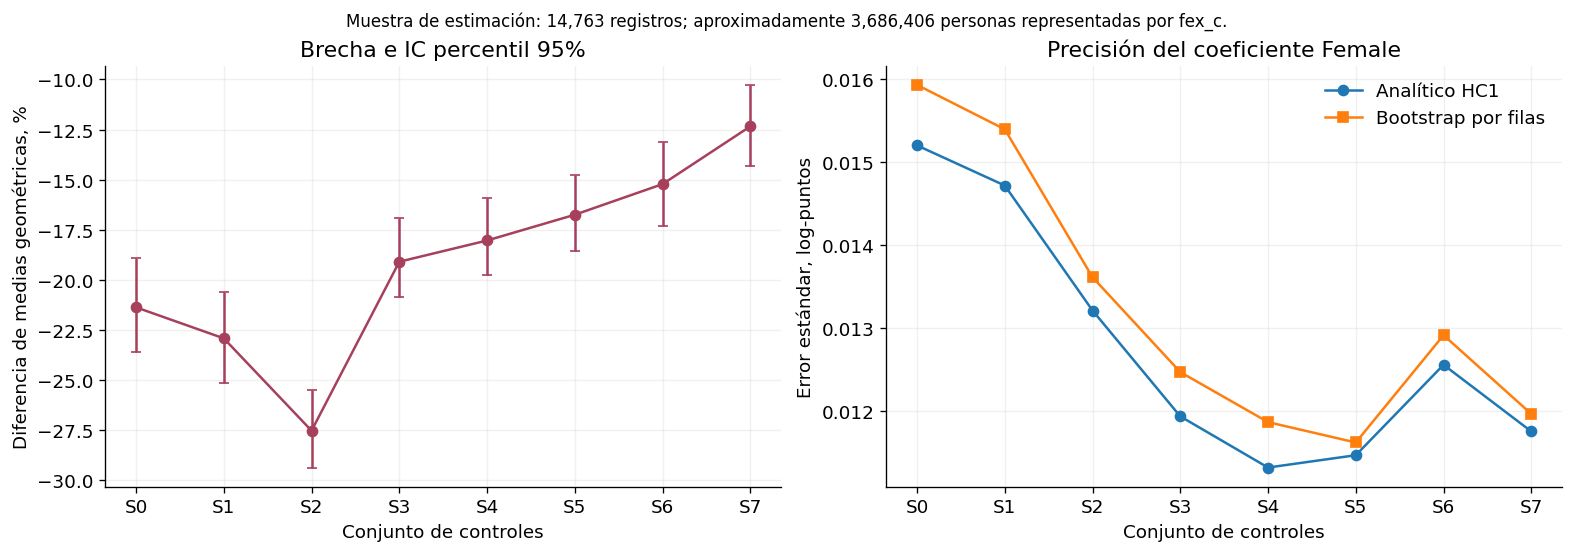

In [3]:
fits,escalera=a.estimar(m)

### 4.2 El teorema en acción: las dos etapas de la especificación preferida
En (a), el eje horizontal muestra $\hat F=W_5\hat\pi_F$ y el vertical el indicador observado. Su diferencia es $r_F$. Como esta es una proyección lineal y no un modelo de probabilidad restringida, $\hat F$ puede salir de $[0,1]$.

En (b) se compara $\hat y=W_5\hat\pi_y$ con $y$; la diferencia vertical es $r_y$. En (c) se dibuja $r_y$ contra $r_F$ y la recta $\hat r_y=\hat\delta_5r_F$. Su pendiente se estima con `fex_c`; la nube dibuja una marca por registro y no codifica su peso en el tamaño. Los residuos ponderados son ortogonales a los controles: $W_5'\Omega r_y=W_5'\Omega r_F=0$. La precisión y el $R^2$ de la tabla corresponden al ajuste completo; el ajuste de la nube de residuos responde a una pregunta parcial.

En (c) también se superpone la pendiente de Female del modelo completo, ajustado con los mismos controles y `fex_c`. Ambas rectas coinciden. El panel (d) verifica los residuos finales en la escala original:
$$\hat u_{FWL}=r_y-r_F\hat\delta_5,\qquad \hat u_{completo}=y-W_5\hat\gamma_5-F\hat\delta_5,\qquad \hat u_{FWL}=\hat u_{completo}.$$
El eje horizontal muestra el residuo del MCO completo ponderado y el vertical el de FWL. La recta de 45° representa igualdad y la anotación reporta la máxima discrepancia numérica. Comparar directamente $r_y$ con el residuo completo sería incorrecto: primero debe descontarse $r_F\hat\delta_5$. La identidad requiere la misma muestra, controles y pesos; aquí MCO completo se refiere a mínimos cuadrados con `fex_c`.

FWL y modelo completo S5, ambos ponderados: 14,763 registros; aproximadamente 3,686,406 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

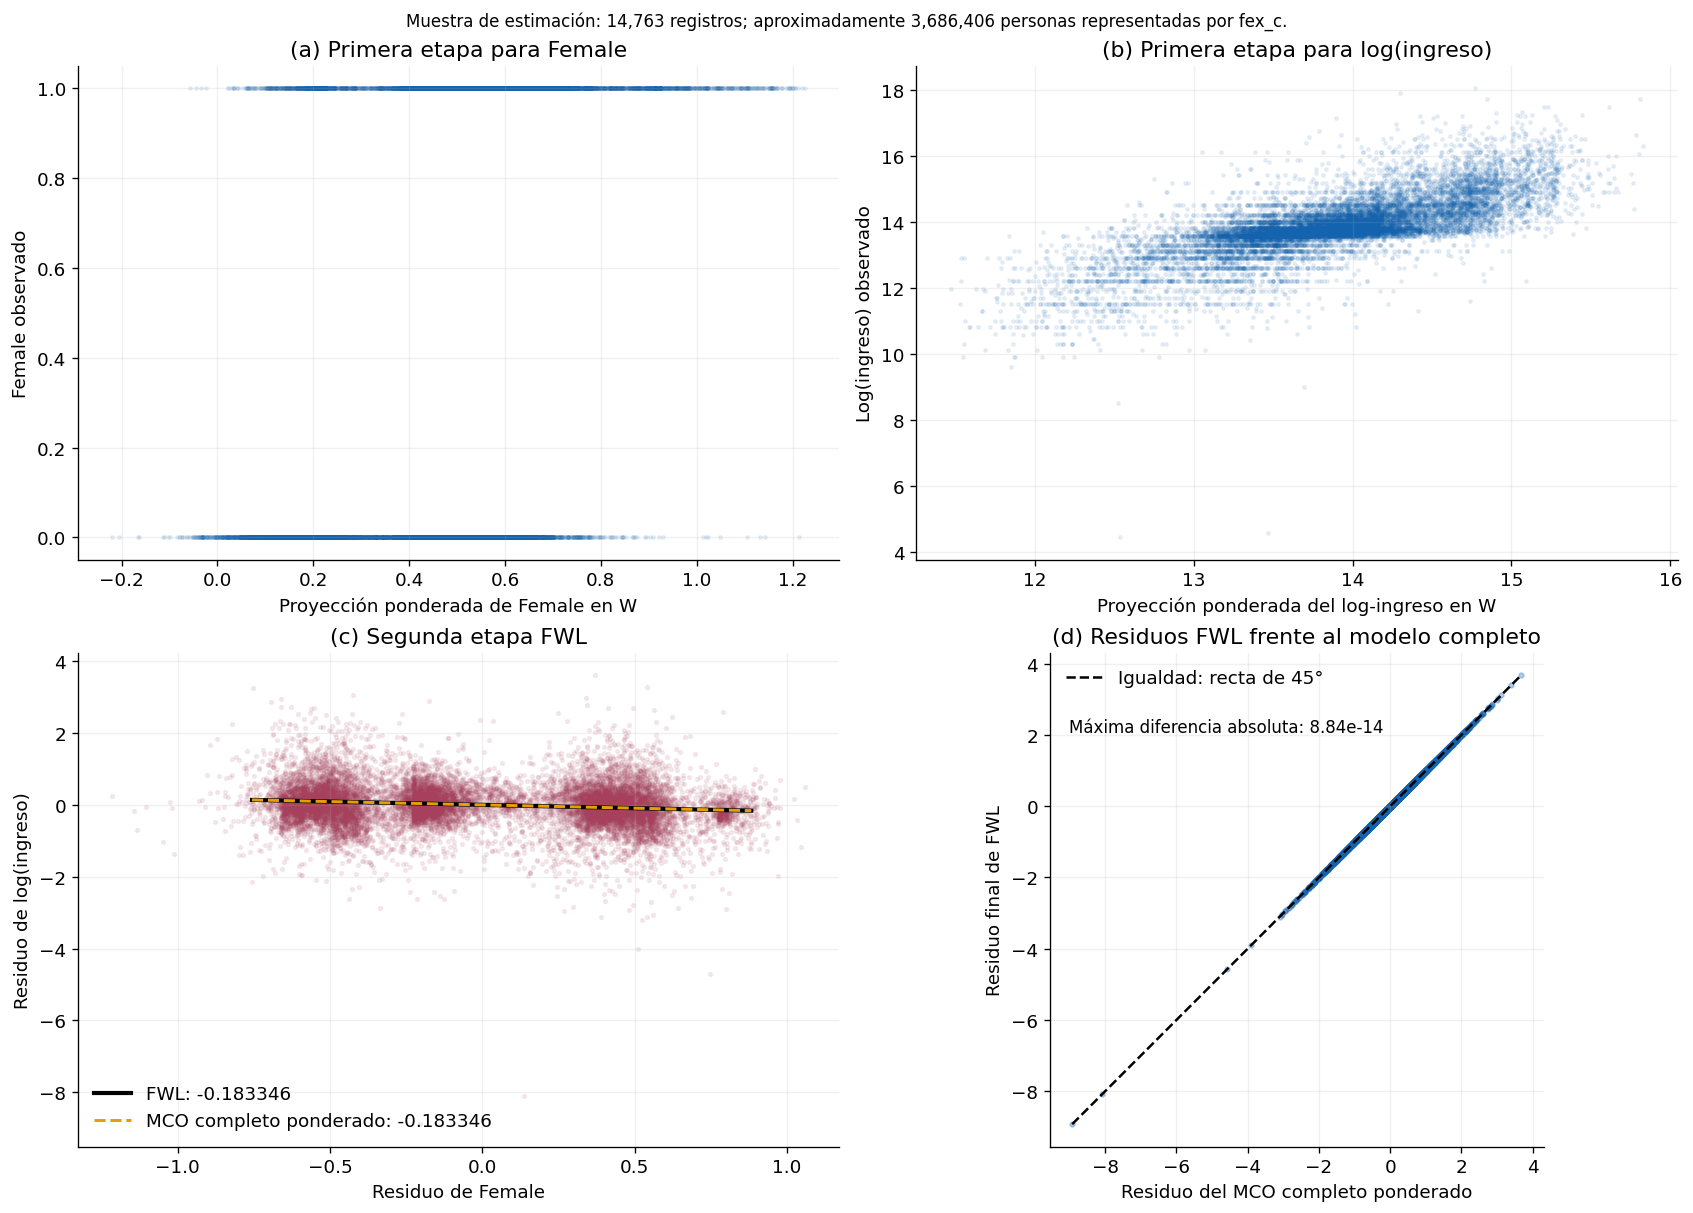

beta_FWL,beta_MCO_completo,max_diferencia_residuos,n_muestra,personas_representadas
-0.1833,-0.1833,0.0000,14763,3686405.7423


In [4]:
a.geometria(m,fits)

## 5. Perfiles edad-ingreso por sexo
### 5.1 Especificación
$$y_i=\alpha+\beta_1A_i+\beta_2A_i^2+\delta F_i+\eta_1F_iA_i+\eta_2F_iA_i^2+Z_i'\gamma+u_i.$$
S1 no incluye $Z_i$; S5 incluye educación, horas y horas², vínculo, formalidad, tamaño y grupo ocupacional. Las interacciones permiten picos distintos:
$$\hat A_H^*=-\frac{\hat\beta_1}{2\hat\beta_2},\qquad \hat A_M^*=-\frac{\hat\beta_1+\hat\eta_1}{2(\hat\beta_2+\hat\eta_2)}.$$
Cada curva evalúa $Z$ en la misma distribución ponderada para ambos sexos. La brecha por edad es $\hat\delta+\hat\eta_1a+\hat\eta_2a^2$, con banda puntual derivada de la covarianza HC1 de esos tres coeficientes. Esta especificación extendida se distingue de S5 aditiva, que impone una brecha constante.

Se reportan IC percentiles de 1,000 réplicas y delta. En el panel (d), las líneas verticales son las medias de las distribuciones bootstrap de los picos, $\bar A_s^*=B^{-1}\sum_b\hat A_{s,b}^*$; las leyendas muestran sus valores. No deben confundirse con los picos estimados en la muestra original que aparecen en la tabla.

Los cuatro paneles se identifican como (a), (b), (c) y (d). Las líneas verticales de (a) y (b) muestran la media bootstrap del pico de cada sexo para S1 y S5, respectivamente, con su valor en la leyenda; son el mismo tipo de referencia que las líneas de (d). No son la edad media de hombres o mujeres ni necesariamente el máximo exacto de la curva ajustada. Ambos perfiles de cada especificación se estiman conjuntamente con toda la muestra: la tabla distingue población del ajuste y población observada de cada sexo.

Ajuste conjunto de S1 y S5 con interacciones por sexo: 14,763 registros; aproximadamente 3,686,406 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

modelo,sexo,pico,media_bootstrap,EE_delta,IC_delta_inf,IC_delta_sup,IC_percentil_inf,IC_percentil_sup,replicas_sin_maximo,n_ajuste,personas_ajuste,n_sexo,personas_sexo
S1,Hombres,43.5329,43.5683,0.4036,42.7419,44.3239,42.7648,44.3880,0,14763,3686405.7423,7774,1957870.0974
S1,Mujeres,37.7308,37.7354,0.3977,36.9513,38.5102,36.9383,38.4799,0,14763,3686405.7423,6989,1728535.6449
S5,Hombres,49.8686,49.9811,0.9543,47.9982,51.7389,48.2667,52.0330,0,14763,3686405.7423,7774,1957870.0974
S5,Mujeres,46.0490,46.1118,0.8845,44.3154,47.7827,44.5517,48.0151,0,14763,3686405.7423,6989,1728535.6449


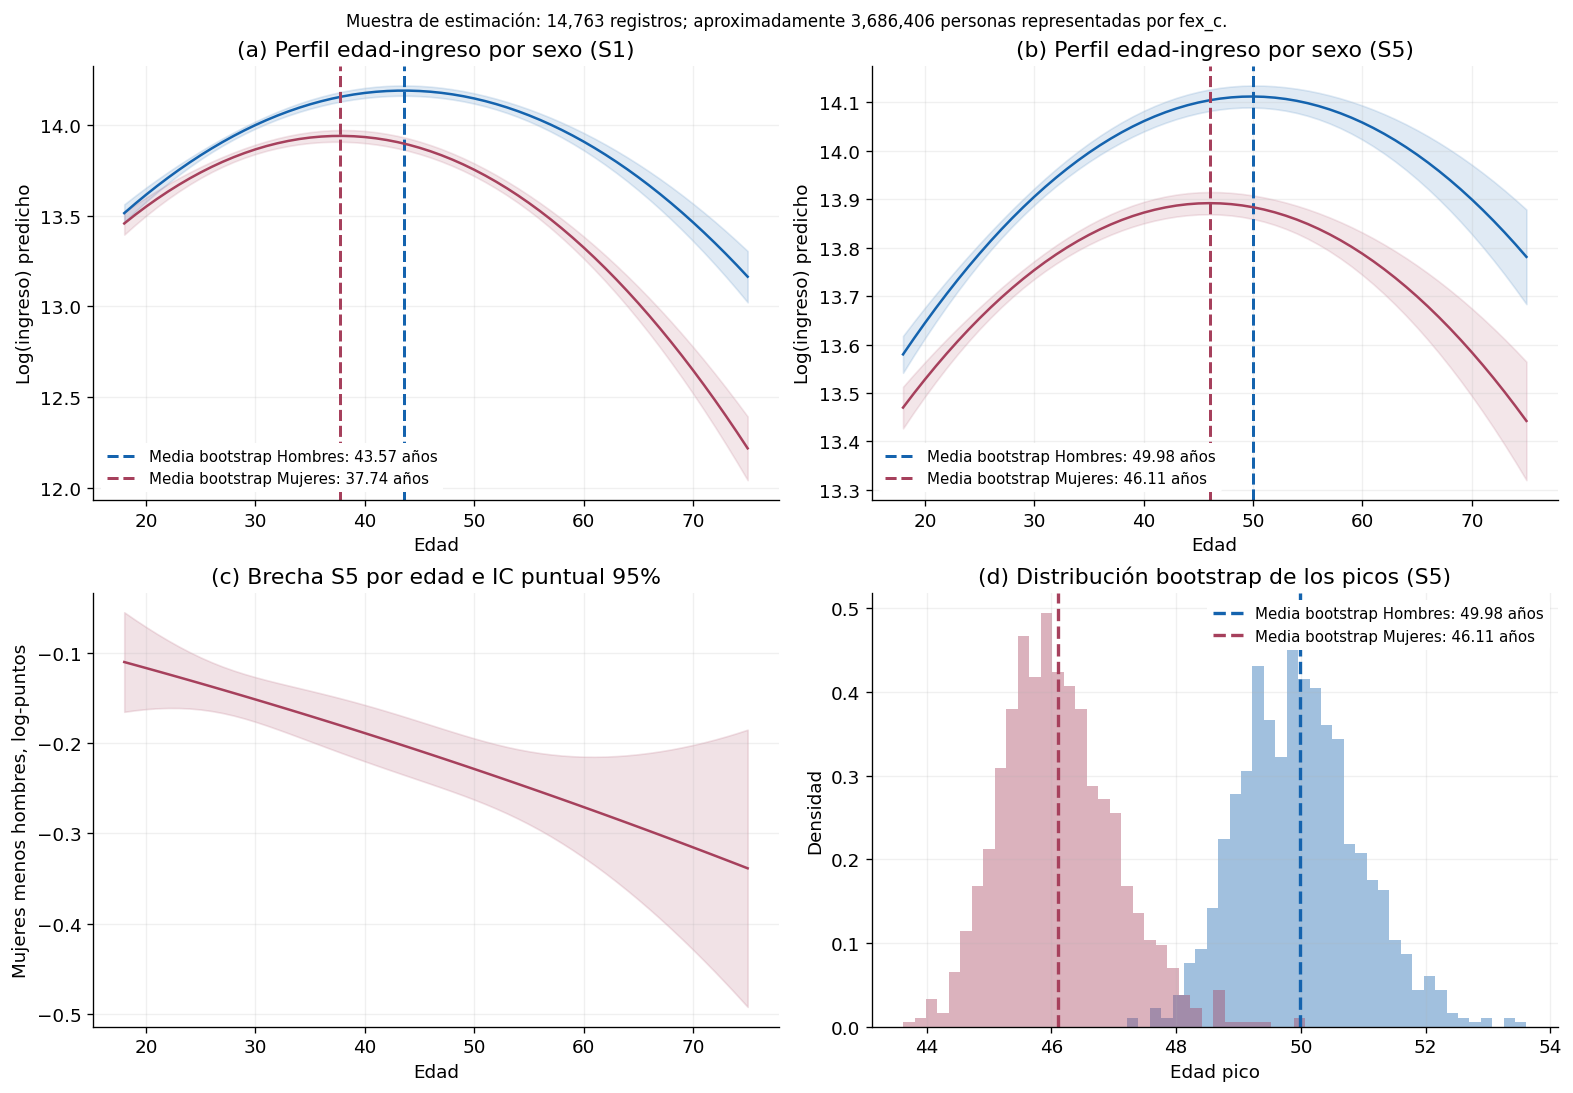

In [5]:
picos=a.perfiles(m)

## 6. Heterogeneidad
### 6.1 Subgrupos
Para cada grupo $G$ definido por educación, formalidad, vínculo o edad se vuelve a estimar, usando solamente sus observaciones,
$$\hat\theta_{s,G}=\arg\min_{\alpha,\delta,\gamma}\sum_{i\in G}w_i(y_i-\alpha-\delta F_i-Z_{s,i}'\gamma)^2.$$
En S0, $Z_s$ está vacío; en S5 contiene los controles preferidos. El gráfico presenta $\hat\delta_{s,G}\pm1.96EE_{HC1}(\hat\delta_{s,G})$. Los controles constantes dentro del grupo o redundantes no aumentan el rango efectivo. FWL requiere variación residual de Female dentro de cada grupo. Los grupos pueden superponerse, por lo que los puntos no constituyen estimaciones independientes. Las diferencias entre S0 y S5 son comparaciones descriptivas condicionadas en distintos observables.

Referencia; la tabla informa la expansión de cada subgrupo: 14,763 registros; aproximadamente 3,686,406 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

grupo,modelo,n,personas_representadas,beta,EE_HC1,IC_inf,IC_sup
Sin terciaria,S0,8649,2183348.5740,-0.3987,0.0158,-0.4296,-0.3677
Sin terciaria,S5,8649,2183348.5740,-0.2281,0.0132,-0.2540,-0.2022
Con terciaria,S0,6114,1503057.1683,-0.1686,0.0246,-0.2169,-0.1203
Con terciaria,S5,6114,1503057.1683,-0.1213,0.0188,-0.1582,-0.0844
Formal,S0,8893,2219030.3595,-0.0788,0.0162,-0.1105,-0.0471
Formal,S5,8893,2219030.3595,-0.1324,0.0136,-0.1592,-0.1057
Informal,S0,5870,1467375.3828,-0.4836,0.0219,-0.5266,-0.4407
Informal,S5,5870,1467375.3828,-0.2971,0.0203,-0.3370,-0.2573
Cuenta propia,S0,4391,1092990.2468,-0.5000,0.0321,-0.5629,-0.4372
Cuenta propia,S5,4391,1092990.2468,-0.3355,0.0273,-0.3891,-0.2819


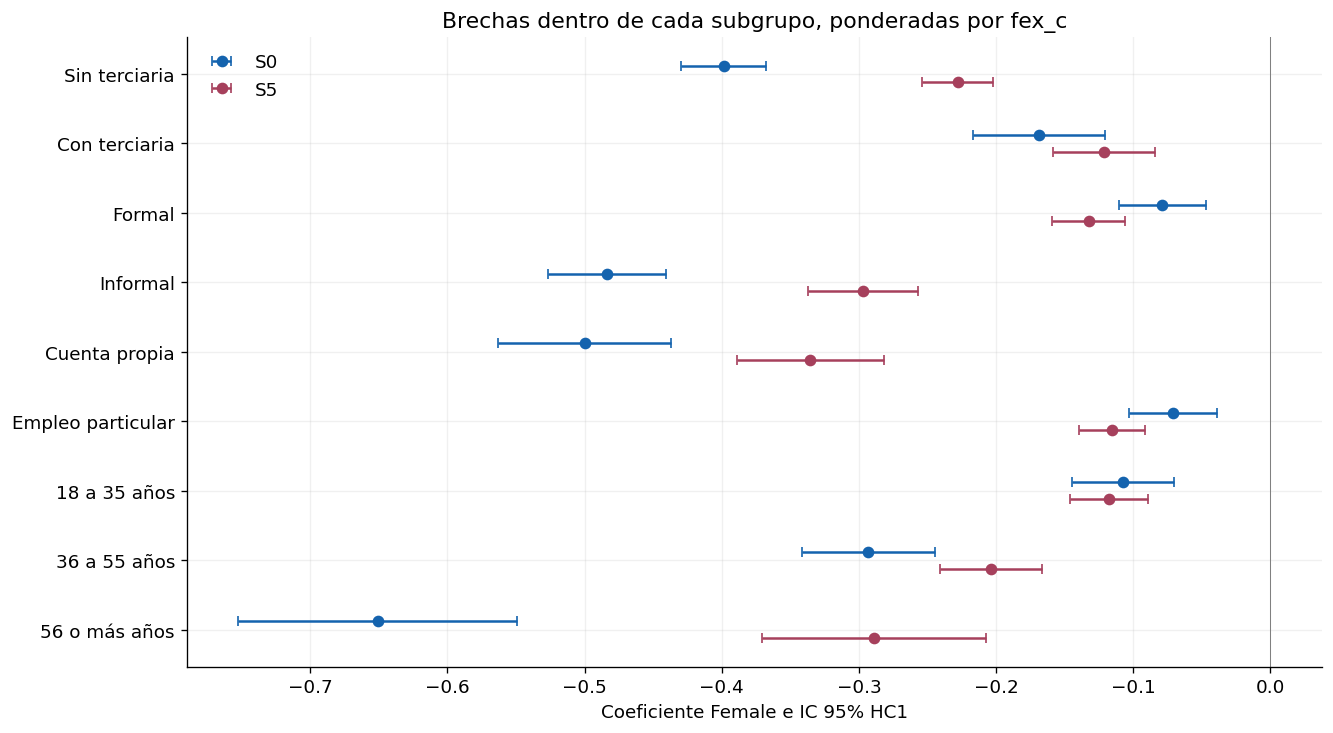

In [6]:
subgrupos=a.subgrupos(m)

## 7. Diagnóstico de leverage e influencia
El coeficiente de S5 resume 14,763 observaciones, y conviene saber si alguna pesa de manera desproporcionada en ese resumen. Siguiendo la complementaria C2, leverage y atipicidad son dos nociones distintas. El leverage $h_{ii}$ es el elemento diagonal de la matriz sombrero del diseño ponderado y mide cuán lejos está $x_i$ del centro de la nube de regresores; no depende de $y_i$. La atipicidad se mide sobre el residuo estudentizado externamente,
$$t_i=\frac{\hat u_i}{\hat\sigma_{(i)}\sqrt{1-h_{ii}}},\qquad \hat\sigma^2_{(i)}=\frac{(n-k)\hat\sigma^2-\hat u_i^2/(1-h_{ii})}{n-k-1},$$
donde $\hat\sigma^2_{(i)}$ excluye a la propia observación $i$, de modo que un dato muy atípico no infla el denominador que debería delatarlo.

Se marca leverage alto si $h_{ii}>3\bar h$ y atípica si $|t_i|>3$. Una observación es influyente solo si cumple ambas condiciones a la vez: estar lejos en los regresores sin sorprender en el resultado no mueve la recta, y sorprender en el resultado desde el centro de la nube tampoco. El ejercicio es descriptivo. Ninguna observación se elimina de la especificación reportada: el interés es acotar cuánto podría moverse la brecha, no depurar la muestra.

Diagnóstico de leverage e influencia sobre S5: 14,763 registros; aproximadamente 3,686,406 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

condicion,n
"Leverage alto, no atípica",270
"Atípica, leverage no alto",212
Ambas (influyente),10


muestra,n,beta_Female,brecha_porcentual
Completa (S5),14763,-0.1833,-16.7520
Sin influyentes (S5),14753,-0.1836,-16.7731


age,female,terciaria,ingreso_mensual
42,0,0,3000000
84,0,1,6000000
33,0,0,3000000
58,1,0,40000
70,0,0,30000
78,0,1,15000000
61,0,1,15000000
24,0,1,200000
56,0,1,14366667
65,0,1,100000


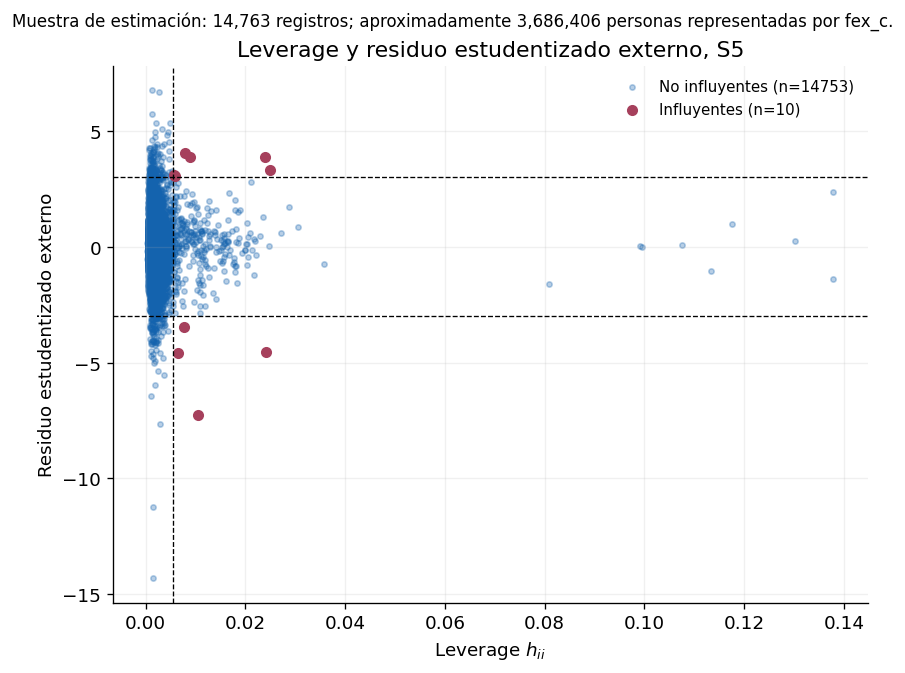

De 14,763 observaciones en S5, 270 tienen leverage alto sin ser atípicas, 212 son atípicas sin leverage alto, y 10 cumplen ambas condiciones a la vez.

Excluir las 10 observaciones influyentes mueve el coeficiente Female de -0.1833 a -0.1836 (brecha de -16.75% a -16.77%).

In [7]:
diagnostico=a.diagnostico(m,fits)

## 8. Conclusiones

In [8]:
s0=escalera.loc[escalera.modelo=='S0'].iloc[0];s5=escalera.loc[escalera.modelo=='S5'].iloc[0]
display(Markdown(f'''La brecha ponderada de medias geométricas pasa de {s0.brecha_porcentual:.2f}% sin controles a {s5.brecha_porcentual:.2f}% en S5. El coeficiente S5 es {s5.beta_Female:.4f}, con error analítico HC1 {s5.EE_analitico_HC1:.4f} y bootstrap {s5.EE_bootstrap:.4f}. El R² ponderado de S5 es {s5.R2_ponderado:.3f}.

Los controles definen la comparación y no eliminan automáticamente selección ni variables omitidas. Las interacciones con edad permiten perfiles diferentes por sexo; sus picos y bandas están condicionados en la forma cuadrática. Las brechas observadas no identifican discriminación causal ni permiten diagnosticar evasión tributaria individual.'''))

La brecha ponderada de medias geométricas pasa de -21.37% sin controles a -16.75% en S5. El coeficiente S5 es -0.1833, con error analítico HC1 0.0115 y bootstrap 0.0116. El R² ponderado de S5 es 0.553.

Los controles definen la comparación y no eliminan automáticamente selección ni variables omitidas. Las interacciones con edad permiten perfiles diferentes por sexo; sus picos y bandas están condicionados en la forma cuadrática. Las brechas observadas no identifican discriminación causal ni permiten diagnosticar evasión tributaria individual.